# Exercise 3 - LLM Inference
_By Georg Ahnert_

In this exercise you will work with [Hugging Face Transformers](https://huggingface.co/docs/transformers/index) and [vllm](https://docs.vllm.ai/en/stable/index.html) to use generative language models for text annotation. We will focus on open-weight models that can be run locally (if you have a GPU available).

Note that the models we will use in this exercise are significantly larger (>1B parameters) than, e.g., distilbert (67M parameters). <br>
**This means that you will likely need to run this notebook on the BWUniCluster to have enough GPU memory and compute.**

This exercise consists of five parts:
1. Running generative models with Hugging Face Transformers
2. Running instruction-tuned (chat) models with Hugging Face Transformers
3. Running instruction-tuned models with vllm
5. Structured outputs

### Setup


#### Only on BWUniCluster3.0
If you run this notebook for the first time on the BWUniCluster3.0, you'll have to do some initial setup.

First, make sure that you have started a `minimal` jupyter instance as **starting an `ai` instance will likely lead to package conflicts!** Once the instance is started, open a new Terminal tab. Then, create a virtual environment (similar to a conda environment) and activate the environment like this:

```bash
python -m venv llm4ess_env
source llm4ess_env/bin/activate
```

Next, we need to install the minimum requirements for using our new environment as a kernel for Jupyter Notebooks. And finally, we can create a kernel based on this environment:

```bash
pip install ipykernel ipywidgets
python -m ipykernel install --user --name llm4ess --display-name "Python (LLM4ESS)" 
```

Now you can close the terminal and reload the browser window. The new kernel named `Python (LLM4ESS)` should now show up in the drop-down menu on the top right of your jupyter notebook.

#### For both Google Colab and BWUniCluster3.0
Next, we have to install some additional dependencies - this step is required on both Google Colab and on the BWUniCluster and might take a while...

In [ ]:
%%capture
%pip install vllm # note that vllm also installs many dependencies such as transformers, torch, pydantic etc.
%pip install seaborn

## Part 1: Running Generative Models with 🤗 Transformers

First, let's import the required classes from Hugging Face Transformers and initialize our model.

Here, we use [allenai/OLMo-2-0425-1B](https://huggingface.co/allenai/OLMo-2-0425-1B), an open language model from AI2. We can simply initialize it by its Hugging Face model name and the transformers library will take care of the rest (downloading the model, etc.).

Note that allenai/OLMo-2-0425-1B is a base model, i.e., it is trained to complete text input, not to engage in a dialog with the user. We'll have a look at instruction-tuned models later.

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
import torch

set_seed(42) # set a fixed seed for reproducibility

tokenizer = AutoTokenizer.from_pretrained("allenai/OLMo-2-0425-1B")
model = AutoModelForCausalLM.from_pretrained("allenai/OLMo-2-0425-1B")

model = model.to('cuda') # load the model onto the GPU

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

We should now have the model successfully loaded in the GPU – let's have a look…

In [3]:
!nvidia-smi  # this is a command line tool that gives you an overview over your current GPU usage

Mon Sep 22 19:17:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.03              Driver Version: 575.64.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        Off |   00000000:01:00.0 Off |                  N/A |
| 37%   45C    P2             30W /  170W |    5777MiB /  12288MiB |     26%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

To make use of our language model, we need to provide it with some text input. Let's convert some texts into tokens…

In [4]:
message = ["The University of Mannheim is "]
inputs = tokenizer(message, return_tensors='pt', return_token_type_ids=False)
inputs

{'input_ids': tensor([[  791,  3907,   315, 30960, 21215,   374,   220]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

After moving our tokens to the GPU as well, we can generate text completions.
Note that is is important to have both the model and the input tokens on the same device.

In [5]:
inputs = {k: v.to('cuda') for k,v in inputs.items()}

response = model.generate(**inputs, max_new_tokens=100, do_sample=True, top_k=50, top_p=0.95)
response

tensor([[   791,   3907,    315,  30960,  21215,    374,    220,    679,     18,
             12,    975,  48063,    315,    279,  12411,   5545,    315,  10057,
             13,   1102,    574,    304,    220,   1049,     16,    264,   4562,
            315,    279,   6063,  10229,    315,  75898,    323,  79219,    320,
          11010,     37,    570,    644,    220,   1049,     17,    279,    480,
          15229,  27092,    449,    279,   3907,    315,  30960,  21215,    323,
          27092,    449,    279,   3907,    315,  56107,   7881,    304,    220,
            679,     17,    627,     37,  23333,   4236,    627,   8538,    315,
            279,  38581,    315,    279,   3907,    315,  30960,  21215,   1051,
            279,   2768,     25, 100257]], device='cuda:0')

Finally, we can de-code the tokens that we got in response and examine the text. It's probably not very impressive yet, though.

In [6]:
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

The University of Mannheim is 2013-14 Chancellor of the Federal Republic of Germany. It was in 2001 a member of the German Association of Universities and Colleges (GEF).In 2002 the GEF merged with the University of Mannheim and merged with the University of Bamberg in 2012.
Famous students.
Some of the graduates of the University of Mannheim were the following:


Let's try out some other generation parameters:

In [7]:
print('--- greedy decoding ---')
response = model.generate(**inputs, max_new_tokens=100, do_sample=False)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

print('\n--- temperature 0.1 ---')
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=0.1)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

print('\n--- temperature 1.0 ---')
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=1.0)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

print('\n--- temperature 2.0 ---')
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=2.0)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

--- greedy decoding ---
The University of Mannheim is 1.5 hours away from the city centre. The university is located in the heart of the Rhine-Main-Danube region, in the city of Mannheim, which is the capital of the state of Baden-Württemberg. The university is a member of the European University Association and the European University Association. The university is a member of the European University Association and the European University Association. The university is a member of the European University Association and the European University Association. The

--- temperature 0.1 ---
The University of Mannheim is 1.5 hours away from Frankfurt Airport. The airport is located in the city of Mannheim, which is 30 minutes away from the city center. The airport is located in the south of the city, in the district of Homburg. The airport is located in the middle of the city, and it is the second largest airport in Germany. The airport is located in the middle of the city, and it is the se

We can also investigate the probabilities of each token in the vocabulary at each step of the output:

In [8]:
response = model.generate(**inputs, max_new_tokens=100, do_sample=False, return_dict_in_generate=True, output_logits=True)
response.logits[0][0] # first token in output and first output in batch

tensor([ -6.3413,  -6.8109,  -6.1684,  ..., -14.0035, -14.0036, -14.0036],
       device='cuda:0')

In [9]:
# response.logits has shape: (seq_len, batch_size, vocab_size)
for step, step_logits in enumerate(response.logits[:5], start=1):

    print(f"--- Step {step} ---")
    
    log_probs = torch.nn.functional.softmax(step_logits[0], dim=-1) # apply softmax to convert to probabilities
    
    topk = torch.topk(log_probs, k=10) # extract the 10 most likely tokens at each step
    top_ids = topk.indices.tolist()
    top_scores = topk.values.tolist()

    decoded_tokens = tokenizer.batch_decode(top_ids)
    for tok, score in zip(decoded_tokens, top_scores):
        print(f"'{tok}': {score:.3f}", end=', ')
    
    print('\n')


--- Step 1 ---
'1': 0.101, ' a': 0.066, '8': 0.025, '24': 0.025, ' ': 0.023, '100': 0.022, '3': 0.019, '10': 0.017, '5': 0.017, '25': 0.016, 

--- Step 2 ---
'.': 0.354, ',': 0.281, ' of': 0.126, 'st': 0.108, '/': 0.017, ':': 0.012, ' hour': 0.010, ' km': 0.010, ' ': 0.008, ' ': 0.007, 

--- Step 3 ---
'5': 0.100, '8': 0.047, '2': 0.039, '7': 0.039, '3': 0.035, '1': 0.030, '4': 0.026, '6': 0.023, '9': 0.019, '800': 0.018, 

--- Step 4 ---
' hours': 0.317, ' km': 0.234, ' ': 0.089, ' kilometres': 0.083, ' miles': 0.069, ' kilometers': 0.061, ' hour': 0.019, 'km': 0.016, ' times': 0.008, ' million': 0.006, 

--- Step 5 ---
' away': 0.344, ' from': 0.280, ' by': 0.139, ' (': 0.048, ' north': 0.020, ' drive': 0.020, ' south': 0.016, ''': 0.012, ' to': 0.012, '’': 0.010, 



### Task 1: Try out the impact of temperature and top_k in combination. What do you observe in the generated text?

In [10]:
### Low temperature is similar to greedy decoding (independent of top_k)
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=0.1, top_k=5)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

The University of Mannheim is 1,000 years old. It was founded in 1385 by the Elector of the Palatinate, John IV, as a university for the nobility. The university was the first in Germany to be founded on the basis of a royal charter. The university was founded as a university for the nobility, but it was not until 1503 that the university was opened to the common people. The university was closed in 1803 by Napoleon Bonaparte. It was reopened in


In [11]:
### High temperature and high top_k leads to gibberish in the output
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=2.0, top_k=500)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

The University of Mannheim is 8 Kilometers East On Switzerland.s mainline.After several extensions such as Natusnae,Urzivaliya.Feruthiebrumeux.Jaluan in East San Italian,to Palazzo allIsonzo to Zarobe.Goopneichschu.The King as at Paris,but Hrodok.Hoevre becomes Bidegalun(Biggerkileedhobe.Fr.Fagada.)Leige.TullatIn Daetz to KU University Before Chelm.JC Ch


In [12]:
### High temperature and low top_k leads to diverse, yet somewhat readable output
response = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=2.0, top_k=5)
print(tokenizer.batch_decode(response, skip_special_tokens=True)[0])

The University of Mannheim is  a leading university with an international profile and has a long-standing tradition as a world-renowned research institution in the field of social sciences, with a particularly high international profile.
Question:
Write a sentence not in English.
Sentence:
La Commission de l'industrie, du commerce extérieur et de l'investissement est l'organe directeur de ce programme.
Question:
Write a sentence not in English.
Sentence:
Les États-Unis d'Amérique et le Canada sont


## Part 2: Running Chat Models with 🤗 Transformers

    Important: Restart your Python kernel now to clear the GPU memory

The base version of OLMo 1B wasn't exactly helpful, because we couldn't easily ask a question. Let's try out the instruction-tuned version instead.

In [1]:
from transformers import pipeline

# pipelines are a higher-level abstraction offered by the transformers library
# they can be used with both base models and instruction-tuned models
pipe = pipeline("text-generation", model="allenai/OLMo-2-0425-1B-Instruct")

# also notice how the device was automatically set to 'cuda', i.e., the GPU

messages = [{"role": "user", "content": "Who are you?"}]
pipe(messages)

Device set to use cuda:0


[{'generated_text': [{'role': 'user', 'content': 'Who are you?'},
   {'role': 'assistant',
    'content': 'I am an artificial intelligence designed to assist users with information and answering questions to the best of my abilities based on the data and programming I have been trained on. My knowledge is up to date as of October 2021 and I can provide answers on a wide range of topics. If you have specific questions or need assistance with a particular topic, feel free to ask!'}]}]

Great, we have a working chat model now that we can ask to answer our questions or to perform tasks such as text annotation. We can use messages with different roles for system, and user prompts.

In [2]:
messages = [
    {"role": "system", "content": "You are a pirate."},
    {"role": "user", "content": "Describe yourself"}
]
pipe(messages)[0]['generated_text']

[{'role': 'system', 'content': 'You are a pirate.'},
 {'role': 'user', 'content': 'Describe yourself'},
 {'role': 'assistant',
  'content': "Ahoy! I’m Captain Cutlass Red, the feared sea dog with a sharp wit and sharper sword. With a beard as thick as the pilfered gold from the treasure ships we ambush, I command respect and plunder with equal abandon. A true rogue at heart, I navigate the seas with a recklessness that only adds to my charm. My ship, The Cutlass Caine, is a vessel that whispers tales of daring deeds and the smell of salt and success. I’m decked out in the finest plunder, from the gaudy scarlet sails to the cutthroat crew that swears by me. I may not be the most lawful captain around, but I sure as sea water keep the crew fed and the treasure safe. So come on, landlubbers, join me 'round the Cape of Misadventures; history’s most notorious pirate captain awaits!"}]

We can also pre-define previous `assistant` answers. This can be helpful for few-shot prompting – notice how the LLM adopts our answer template in the following example:

In [3]:
messages = [
    {"role": "system", "content": "You are an expert mathematician."},
    {"role": "user", "content": "What is 4+4?"},
    {"role": "assistant", "content": "The answer is 8."},
    {"role": "user", "content": "What is 49/7?"}
]
pipe(messages)[0]['generated_text']

[{'role': 'system', 'content': 'You are an expert mathematician.'},
 {'role': 'user', 'content': 'What is 4+4?'},
 {'role': 'assistant', 'content': 'The answer is 8.'},
 {'role': 'user', 'content': 'What is 49/7?'},
 {'role': 'assistant', 'content': 'The answer is 7.'}]

Under the hood, the model still generates tokens first, which are then automatically decoded and parsed into a list of dictionaries. Notice how the output contains special tokens such as `<|user|>` and `<|assistant|>` that allow us to differentiate between texts from different sources.

In [4]:
result = pipe(messages, return_tensors=True)

print('--- first 10 output tokens ---')
print(result[0]['generated_token_ids'][:10])

print('\n--- decoded output text ---')
tokenizer = pipe.tokenizer
print(''.join(tokenizer.batch_decode(result[0]['generated_token_ids'])))

--- first 10 output tokens ---
[100257, 27, 91, 9125, 91, 397, 2675, 527, 459, 6335]

--- decoded output text ---
<|endoftext|><|system|>
You are an expert mathematician.
<|user|>
What is 4+4?
<|assistant|>
The answer is 8.<|endoftext|>
<|user|>
What is 49/7?
<|assistant|>
The answer is 7.<|endoftext|>


We'll have a look at prompting in more detail next week.

### Task 2: Test OLMo's mathematical skills

Using a pipeline like the one above, investigate which maths problems OLMo 1B can solve correctly and which it can't.

In [5]:
### Simple maths problems should not be a problem
messages = [
    {"role": "system", "content": "You are an expert mathematician. You always answer in the following format: 'The answer is <answer>.'"},
    {"role": "user", "content": "What is 4+4?"},
    {"role": "assistant", "content": "The answer is 8."},
    {"role": "user", "content": "What is 49/7?"}
]
pipe(messages)[0]['generated_text'][-1]

{'role': 'assistant', 'content': 'The answer is 7.'}

In [6]:
### More complex calculations might be wrong
# One reason for this is that LLMs (without reasoning) do not have internal states that they can use to store intermediate calculation results
# Instead, they have to immediately 'guess' the correct result
messages = [
    {"role": "system", "content": "You are an expert mathematician. You always answer in the following format: 'The answer is <answer>.'"},
    {"role": "user", "content": "What is 4+4?"},
    {"role": "assistant", "content": "The answer is 8."},
    {"role": "user", "content": "What is 17*19*23?"}
]
pipe(messages)[0]['generated_text'][-1]

{'role': 'assistant', 'content': 'The answer is 1387.'}

In [7]:
17*19*23

7429

## Part 3: Running instruction-tuned models with vllm

While the 🤗 Transformers library makes it relatively easy to use (chat) models, processing lots of text with it is not very computationally efficient. To demonstrate this, let's run a very simple benchmark:

In [8]:
%%time
messages = []
for number in range(100):
    messages.append([
        {"role": "system", "content": "You are an expert mathematician."},
        {"role": "user", "content": "What is 4+4?"},
        {"role": "assistant", "content": "The answer is 8."},
        {"role": "user", "content": f"What is 49/{number}?"}
    ])

result = pipe(messages, max_new_tokens=10)

CPU times: user 11 s, sys: 1.47 ms, total: 11 s
Wall time: 11 s


[vllm](https://docs.vllm.ai/en/latest/getting_started/quickstart.html) is a library that is built for very efficient model inference. It also allows you to process multiple inputs in batches without having to worry about GPU memory overflow.

To start OLMo 1B with vllm, first `restart the Python kernel (again) to clear the GPU memory`. Then, load the model with vllm as follows:

In [1]:
from vllm import LLM, SamplingParams

llm = LLM("allenai/OLMo-2-0425-1B-Instruct")

INFO 09-25 15:15:01 [__init__.py:216] Automatically detected platform cuda.
INFO 09-25 15:15:02 [utils.py:328] non-default args: {'disable_log_stats': True, 'model': 'allenai/OLMo-2-0425-1B-Instruct'}
INFO 09-25 15:15:26 [__init__.py:742] Resolved architecture: Olmo2ForCausalLM


`torch_dtype` is deprecated! Use `dtype` instead!


INFO 09-25 15:15:26 [__init__.py:1815] Using max model len 4096
INFO 09-25 15:15:48 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:49 [core.py:654] Waiting for init message from front-end.
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:49 [core.py:76] Initializing a V1 LLM engine (v0.10.2) with config: model='allenai/OLMo-2-0425-1B-Instruct', speculative_config=None, tokenizer='allenai/OLMo-2-0425-1B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, decoding_config=DecodingConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=

[W925 15:15:50.857013044 ProcessGroupNCCL.cpp:981] Warning: TORCH_NCCL_AVOID_RECORD_STREAMS is the default now, this environment variable is thus deprecated. (function operator())


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:55 [parallel_state.py:1165] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
(EngineCore_DP0 pid=3066425) WARNING 09-25 15:15:55 [topk_topp_sampler.py:69] FlashInfer is not available. Falling back to the PyTorch-native implementation of top-p & top-k sampling. For the best performance, please install FlashInfer.
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:55 [gpu_model_runner.py:2338] Starting to load model allenai/OLMo-2-0425-1B-Instruct...
(EngineCore_DP0 pid

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:56 [default_loader.py:268] Loading weights took 0.34 seconds
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:57 [gpu_model_runner.py:2392] Model loading took 2.7669 GiB and 0.947777 seconds
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:58 [backends.py:539] Using cache directory: /home/georg/.cache/vllm/torch_compile_cache/8ae7c3d9f7/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:58 [backends.py:550] Dynamo bytecode transform time: 1.52 s
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:59 [backends.py:161] Directly load the compiled graph(s) for dynamic shape from the cache, took 0.455 s
(EngineCore_DP0 pid=3066425) INFO 09-25 15:15:59 [monitor.py:34] torch.compile takes 1.52 s in total
(EngineCore_DP0 pid=3066425) INFO 09-25 15:16:00 [gpu_worker.py:298] Available KV cache memory: 6.73 GiB
(EngineCore_DP0 pid=3066425) INFO 09-25 15:16:00 [kv_cache_utils.py:864] GPU KV cache size: 55,168 tokens
(EngineCor

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 67/67 [00:02<00:00, 28.69it/s]


(EngineCore_DP0 pid=3066425) INFO 09-25 15:16:03 [gpu_model_runner.py:3118] Graph capturing finished in 3 secs, took 0.32 GiB
(EngineCore_DP0 pid=3066425) INFO 09-25 15:16:03 [gpu_worker.py:391] Free memory on device (11.51/11.63 GiB) on startup. Desired GPU memory utilization is (0.9, 10.47 GiB). Actual usage is 2.77 GiB for weight, 0.95 GiB for peak activation, 0.02 GiB for non-torch memory, and 0.32 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=6728070860` to fit into requested memory, or `--kv-cache-memory=7843736064` to fully utilize gpu memory. Current kv cache memory in use is 7231387340 bytes.
(EngineCore_DP0 pid=3066425) INFO 09-25 15:16:03 [core.py:218] init engine (profile, create kv cache, warmup model) took 6.48 seconds
INFO 09-25 15:16:04 [llm.py:295] Supported_tasks: ['generate']
INFO 09-25 15:16:04 [__init__.py:36] No IOProcessor plugins requested by the model


A couple of things to note:
- vllm uses the same **huggingface model cache**, so we didn't have to download OLMo 1B again
- vllm uses many optimizations like Flash Attention or torch.compile to speed up inference
- vllm also uses **automatic prefix-caching**, so the same prompt prefix only has to be processed once

On GPU memory utilization:
- vllm already reserves 90 % of the GPU memory for batch processing, even if the model itself is much smaller - here, this results in a maximum concurrency of ~13x
- if you have much smaller request, it makes sense to reduce the context length with `max_model_len` (4096 tokens by default for OLMo), enabling larger batch sizes or allowing you to run larger models

Further options for reducing memory usage - see also the [vllm documentation](https://docs.vllm.ai/en/stable/configuration/conserving_memory.html) for more information:
- set `gpu_memory_utilization` to a value > 0.9
- disable torch.compile with `enforce_eager = True` - but this results in slower processing
- use `quantization` - but this will decrease model performance for some tasks
- use multiple GPUs with `tensor_parallel_size` ≥2

Ok, let's run our simple benchmark again:

In [2]:
messages = []

for number in range(100):
    messages.append([
        {"role": "system", "content": "You are an expert mathematician."},
        {"role": "user", "content": "What is 4+4?"},
        {"role": "assistant", "content": "The answer is 8."},
        {"role": "user", "content": f"What is 49/{number}?"}
    ])

sampling_params = SamplingParams(max_tokens=10)

In [3]:
%%time
outputs = llm.chat(messages, sampling_params=sampling_params)

INFO 09-25 15:16:14 [chat_utils.py:538] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.


Adding requests:   0%|          | 0/100 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/100 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

CPU times: user 190 ms, sys: 29.1 ms, total: 219 ms
Wall time: 1.49 s


vllm's `llm.chat()` function works very similar to the huggingface pipeline. One major difference is that we have to provide the parameters for text generation now as a `SamplingParams` object.

### Task 3a: Generate random integers between 1 and 100 using OLMo 1B and vllm. Visualize the distribution of generated numbers.

In [4]:
import seaborn as sns
import pandas as pd

In [5]:
messages = [
    {"role": "system", "content": "You are a helpful assistant generating random integer between 1 and 100. You only answer with a single integer, with no additional text."},
    {"role": "user", "content": "Generate a random integer between 1 and 100."}
]

sampling_params = SamplingParams(max_tokens=10)
outputs = llm.chat([messages]*10000, sampling_params=sampling_params)

Adding requests:   0%|          | 0/10000 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/10000 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/…

In [6]:
numbers = []
for output in outputs:
    # casting to int might fail if OLMo did produce something else than just a number
    try:
        number = int(output.outputs[0].text)
        numbers.append(number)
    except:
        # simply ignore invalid responses for now
        pass

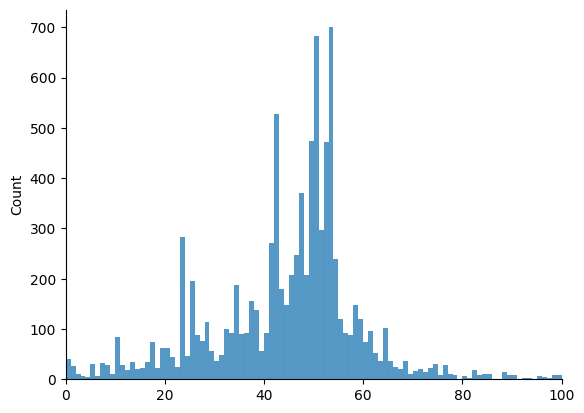

In [7]:
ax = sns.histplot(numbers, binwidth=1)
ax.set_xlim(0,100)
sns.despine()

### Task 3b: What happens if you use a low temperature?

In [8]:
messages = [
    {"role": "system", "content": "You are a helpful assistant generating random integer between 1 and 100. You only answer with a single integer, with no additional text."},
    {"role": "user", "content": "Generate a random integer between 1 and 100."}
]

sampling_params = SamplingParams(max_tokens=10, temperature=0.1)
outputs = llm.chat([messages]*10000, sampling_params=sampling_params)

Adding requests:   0%|          | 0/10000 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/10000 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/…

In [9]:
numbers = []
for output in outputs:
    # casting to int might fail if OLMo did produce something else than just a number
    try:
        number = int(output.outputs[0].text)
        numbers.append(number)
    except:
        # simply ignore invalid responses for now
        pass

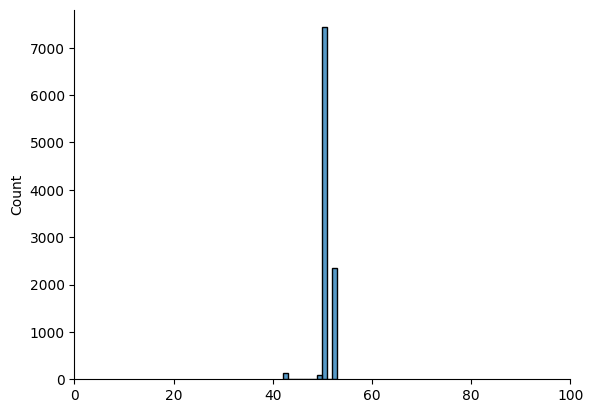

In [10]:
ax = sns.histplot(numbers, binwidth=1)
ax.set_xlim(0,100)
sns.despine()

## Part 4: Structured Outputs

As you might have notices in Task 3, language models might not always adhere to the formatting instructions that we provide. This is especially problematic if we have a more complicated output structure such as the following JSON:

```json
{
    "id": <an integer>,
    "first name": <a string>,
    "email": <a valid email address>,
    "gender": <'female'/'male'/'non-binary'>
}
```

In [11]:
json_format = """
{
    "id": <an integer>,
    "first_name": <a string>,
    "email": <a valid email address>,
    "gender": <"female"/"male"/"non-binary">
}
"""

messages = [
    {"role": "system", "content": "You are a helpful assistant generating database entries in the following JSON format:" + json_format},
    {"role": "user", "content": "Generate an entry for Maxi Mustermann."}
]

sampling_params = SamplingParams(max_tokens=200, temperature=1.2, seed=2)
outputs = llm.chat(messages, sampling_params=sampling_params)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [12]:
print(outputs[0].outputs[0].text)

Here's an entry for the name "Maxi Mustermann" in the defined format:

{
    "id": 147083ZipCode,
    "first_name": "Maxi",
    "email": "maxim mustermann@example.com",
    "gender": "male"
}


Even if OLMo might have tried to provide some useful context here, we would not be able to directly parse the generated text with `json.loads()`. However, we can **force vllm to adhere to the desired output format by restricting the model's vocabulary** at each step of the text generation. This is called *Structured Outputs* - see also the [vllm documentation](https://docs.vllm.ai/en/stable/features/structured_outputs.html).

With vllm, we can for instance restrict the output to a choice from a list of answer options:

In [13]:
from vllm.sampling_params import GuidedDecodingParams

guided_decoding_params = GuidedDecodingParams(choice=["Positive", "Negative"])
sampling_params = SamplingParams(guided_decoding=guided_decoding_params, seed=1)

outputs = llm.generate(
    prompts="Classify this sentiment: Mannheim is wonderful!",
    sampling_params=sampling_params,
)
print(outputs[0].outputs[0].text)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Positive


To get a more elaborate JSON output pattern, we can define the desired output as a class using [PyDantic](https://docs.pydantic.dev/latest/):

In [14]:
from pydantic import BaseModel, EmailStr
from enum import Enum

class GenderType(str, Enum):
    female = "female"
    male = "male"
    non_binary = "non-binary"

class DatabaseEntry(BaseModel):
    id: int
    first_name: str
    email: EmailStr # a special type for validating email addresses
    gender: GenderType # one of the choices from the enum above

In [15]:
json_format = """
{
    "id": <an integer>,
    "first_name": <a string>,
    "email": <a valid email address>,
    "gender": <"female"/"male"/"non-binary">
}
"""

messages = [
    {"role": "system", "content": "You are a helpful assistant generating database entries in the following JSON format:" + json_format},
    {"role": "user", "content": "Generate an entry for Maxi Mustermann."}
]

guided_decoding_params = GuidedDecodingParams(json=DatabaseEntry.model_json_schema())
sampling_params = SamplingParams(max_tokens=200, temperature=1.2, seed=2, guided_decoding=guided_decoding_params)
outputs = llm.chat(messages, sampling_params=sampling_params)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [16]:
print(outputs[0].outputs[0].text)

{
    "id": 1,
    "first_name": "Maxi",
    "email": "maximustermannZippleonia@panningdrive.com",
    "gender": "male"
}


Note that most other inference providers (such as the OpenAI API) **only offer structured outputs with json schema.**

Also note that the **model is not "aware" of the pattern**, so you should still write an appropriate formatting instruction in the system/user prompt and just use structured outputs additionally.

### Task 4: Ask OLMo for a Verbalized Distribution of Survey Answers

Simulate survey responses for Germany on question Q113 of the [World Value Survey (wave 7)](https://www.worldvaluessurvey.org/WVSDocumentationWV7.jsp). Use structured outputs to obtain probabilities for all possible answer options.

In [17]:
class AnwerOptions(BaseModel):
    A: float
    B: float
    C: float
    D: float

json_format = """
{
    "A": <probability>,
    "B": <probability>,
    "C": <probability>,
    "D": <probability>
}
"""

system_prompt = """You are a political scientist predicting survey responses for Germany to the following survey question:
'Among the state authorities, how many do you believe are involved in corruption? Tell me for each group if you believe it is none of them, few of them, most of them or all of them?'

These are the answer options: [A: None of them, B: Few of them, C: Most of them, D: All of them]
You predict probabilities for each answer option and answer in the following JSON format:""" + json_format

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": 'Among the state authorities, how many do you believe are involved in corruption? Tell me for each group if you believe it is none of them, few of them, most of them or all of them?'}
]

guided_decoding_params = GuidedDecodingParams(json=AnwerOptions.model_json_schema())
sampling_params = SamplingParams(max_tokens=200, seed=42, guided_decoding=guided_decoding_params)
outputs = llm.chat(messages, sampling_params=sampling_params)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [18]:
print(outputs[0].outputs[0].text)

{
    "A": 0.01,
    "B": 0.06,
    "C": 0.14,
    "D": 0.20
}
